# Réplica: Convergencia y disparidades socioeconómicas en el Perú### Adaptado de Duran et al. (2024) — EC-585, UNSCH**Autora:** Karen Medrano — Trabajo individual## 0. Configuración inicial

In [1]:
R.version.string

[1] "R version 4.6.0 (2026-04-24)"

In [2]:
system("apt-get update -qq")

system("apt-get install -y -qq r-cran-sf")

In [3]:
library(sf)

Linking to GEOS 3.12.1, GDAL 3.4.3, PROJ 8.2.1; sf_use_s2() is TRUE


Linked against: 3.12.1-CAPI-1.18.1 compiled against: 3.10.2-CAPI-1.16.0

It is probably a good idea to reinstall sf (and maybe lwgeom too)



In [4]:
library(readxl); library(dplyr); library(purrr); library(sf)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## 1. Extracción de datos### 1.1 PBI departamental (INEI, 2007-2022)

In [5]:
install.packages(c("readxl", "dplyr", "purrr"))

library(readxl); library(dplyr); library(purrr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [6]:
repo_base <- "https://raw.githubusercontent.com/karenmedrano2026/replica-convergencia-peru-ec585/main/data/raw/"

url_pbi <- paste0(repo_base, "PBI%20departamental/")

sufijos <- ifelse(1:24 %in% c(12, 15, 24), "18", "17")

archivos_pbi <- sprintf("pbi_dep%02d_%s.xlsx", 1:24, sufijos)



extraer_pbi_departamento <- function(nombre_archivo, intentos = 3) {

  destino <- tempfile(fileext = ".xlsx")

  exito <- FALSE

  for (i in 1:intentos) {

    ok <- tryCatch({

      download.file(paste0(url_pbi, nombre_archivo), destino, mode = "wb", quiet = TRUE)

      file.exists(destino) && file.size(destino) > 1000

    }, error = function(e) FALSE)

    if (ok) { exito <- TRUE; break }

    Sys.sleep(10 * i)   # espera 10s, 20s, 30s si falla

  }

  if (!exito) {

    warning(paste("FALLÓ:", nombre_archivo))

    return(data.frame(departamento = NA, anio = NA, pbi_real = NA))

  }

  hoja <- read_excel(destino, sheet = "cuadro1", col_names = FALSE)

  nombre_dpto <- trimws(sub(":.*", "", hoja[[2, 1]]))

  anios <- as.numeric(hoja[7, -1])

  datos_actividades <- sapply(hoja[9:19, -1], as.numeric)

  data.frame(departamento = nombre_dpto, anio = anios,

             pbi_real = colSums(datos_actividades, na.rm = TRUE))

}



lista_pbi <- lapply(archivos_pbi, function(a) {

  Sys.sleep(3)   # pausa más larga entre archivos (antes 1.5s, ahora 3s)

  extraer_pbi_departamento(a)

})



panel_pbi <- bind_rows(lista_pbi)

cat("PBI: filas =", nrow(panel_pbi), "| departamentos únicos =", n_distinct(panel_pbi$departamento, na.rm = TRUE), "\n")

cat("Archivos que fallaron:", sum(is.na(panel_pbi$departamento[!duplicated(panel_pbi$departamento)])), "\n")

print(head(panel_pbi, 10))

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
Warning message in extraer_pbi_departamento(a):
“NAs introduced by coercion”
Warning message in extraer_pbi_departamento(a):
“NAs introduced by coercion”
Warning message in extraer_pbi_departamento(a):
“NAs introduced by coercion”
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
Warning message in extraer_pbi_departamento(a):
“NAs introduced by coercion”
Warning message in extraer_pbi_departamento(a):


PBI: filas = 452 | departamentos únicos = 24 
Archivos que fallaron: 0 
      departamento anio pbi_real
...1      Amazonas 2007  1778775
...2      Amazonas 2008  1930947
...3      Amazonas 2009  2058318
...4      Amazonas 2010  2210682
...5      Amazonas 2011  2287107
...6      Amazonas 2012  2551601
...7      Amazonas 2013  2682266
...8      Amazonas 2014  2824603
...9      Amazonas 2015  2782128
...10     Amazonas 2016  2784366


In [7]:
archivos_faltantes <- c("pbi_dep03_17.xlsx", "pbi_dep18_17.xlsx")



lista_faltantes <- lapply(archivos_faltantes, function(a) {

  Sys.sleep(8)

  extraer_pbi_departamento(a, intentos = 5)

})



panel_faltantes <- bind_rows(lista_faltantes)

print(panel_faltantes)  # confirma que salgan con departamento distinto de NA

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
Warning message in extraer_pbi_departamento(a, intentos = 5):
“NAs introduced by coercion”
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
Warning message in extraer_pbi_departamento(a, intentos = 5):
“NAs introduced by coercion”
Warning message in extraer_pbi_departamento(a, intentos = 5):
“NAs introduced by coercion”
Warning message in extraer_pbi_departamento(a, intentos = 5):
“NAs introduced by coercion”


      departamento anio pbi_real
...1      Apurímac 2007  1824181
...2      Apurímac 2008  1688564
...3      Apurímac 2009  1623801
...4      Apurímac 2010  1765744
...5      Apurímac 2011  1869417
...6      Apurímac 2012  2110908
...7      Apurímac 2013  2342674
...8      Apurímac 2014  2437434
...9      Apurímac 2015  2630345
...10     Apurímac 2016  6343065
...11     Apurímac 2017  7718535
...12     Apurímac 2018  7131314
...13     Apurímac 2019  7170478
...14     Apurímac 2020  6448415
...15     Apurímac 2021  6586239
...16     Apurímac 2022  6290806
...17     Apurímac   NA  6689337
...18        Pasco 2007  5486459
...19        Pasco 2008  5416732
...20        Pasco 2009  5040946
...21        Pasco 2010  4702403
...22        Pasco 2011  4641887
...23        Pasco 2012  4880072
...24        Pasco 2013  4885819
...25        Pasco 2014  5046668
...26        Pasco 2015  5211406
...27        Pasco 2016  5329324
...28        Pasco 2017  5333755
...29        Pasco 2018  5337612
...30     

In [8]:
panel_pbi_completo <- bind_rows(panel_pbi, panel_faltantes) %>%

  filter(!is.na(departamento), !is.na(anio))



cat("PBI FINAL: filas =", nrow(panel_pbi_completo),

    "| departamentos únicos =", n_distinct(panel_pbi_completo$departamento), "\n")



# Verificación rápida: ¿todos entre 2007 y 2019?

panel_pbi_completo %>% filter(anio %in% c(2007, 2019)) %>% count(anio)

PBI FINAL: filas = 416 | departamentos únicos = 24 


anio,n
<dbl>,<int>
2007,26
2019,26


### 1.2 Población departamental (INEI)

In [9]:
url_pob <- paste0(repo_base, URLencode("población/proy_03_4.xlsx", reserved = FALSE))

destino_pob <- tempfile(fileext = ".xlsx")



for (i in 1:5) {

  ok <- tryCatch({

    download.file(url_pob, destino_pob, mode = "wb", quiet = TRUE)

    file.exists(destino_pob) && file.size(destino_pob) > 1000

  }, error = function(e) FALSE)

  if (ok) break

  Sys.sleep(10 * i)

}



# Revisemos primero qué hojas tiene y cómo se ve la primera

excel_sheets(destino_pob)

[1] "2000-2002" "2003-2005" "2006-2008" "2009-2011" "2012-2014" "2015-2017"
[7] "2018-2020" "2021-2023" "2024-2026"

In [10]:
hoja_pob <- read_excel(destino_pob, sheet = "2006-2008", col_names = FALSE)

print(hoja_pob[1:15, 1:10])

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`


# A tibble: 15 × 10
   ...1                    ...2  ...3  ...4  ...5  ...6  ...7  ...8  ...9  ...10
   <chr>                   <chr> <chr> <chr> <chr> <chr> <chr> <chr> <chr> <chr>
 1 POBLACIÓN ESTIMADA AL … NA    NA    NA    NA    NA    NA    NA    NA    NA   
 2 NA                      NA    NA    NA    NA    NA    NA    NA    NA    NA   
 3 Ubigeo                  Depa… 2006  NA    NA    2007  NA    NA    2008  NA   
 4 NA                      NA    Total Homb… Mujer Total Homb… Mujer Total Homb…
 5 NA                      NA    NA    NA    NA    NA    NA    NA    NA    NA   
 6 000000                  Perú  2793… 1389… 1403… 2812… 1399… 1412… 2830… 1408…
 7 NA                      NA    NA    NA    NA    NA    NA    NA    NA    NA   
 8 010000                  Amaz… 4078… 2109… 1968… 4078… 2108… 1970… 4076… 2106…
 9 020000                  Ánca… 1095… 5466… 5492… 1096… 5472… 5489… 1096… 5476…
10 030000                  Apur… 4366… 2218… 2148… 4351… 2212… 2138… 4331… 2204…
11 04000

In [11]:
extraer_poblacion_anio <- function(destino, hoja, anio_objetivo) {

  datos <- read_excel(destino, sheet = hoja, col_names = FALSE)



  fila_anios <- as.character(unlist(datos[3, ]))

  col_total <- which(fila_anios == as.character(anio_objetivo))[1]



  filas_datos <- datos[6:nrow(datos), ]

  ubigeo <- unlist(filas_datos[[1]])

  nombre <- unlist(filas_datos[[2]])

  poblacion <- as.numeric(unlist(filas_datos[, col_total]))



  df <- data.frame(ubigeo = ubigeo, departamento = nombre, poblacion = poblacion, anio = anio_objetivo)



  # Nos quedamos solo con filas de nivel departamental: UBIGEO termina en "0000", excluyendo el total Perú "000000"

  df <- df[!is.na(df$ubigeo) & nchar(df$ubigeo) == 6 &

           substr(df$ubigeo, 3, 6) == "0000" & df$ubigeo != "000000", ]

  df

}



# ===== Extraer 2007 (hoja "2006-2008") y 2019 (hoja "2018-2020") =====

pob_2007 <- extraer_poblacion_anio(destino_pob, "2006-2008", 2007)

pob_2019 <- extraer_poblacion_anio(destino_pob, "2018-2020", 2019)



panel_poblacion <- bind_rows(pob_2007, pob_2019)



cat("Población: filas =", nrow(panel_poblacion),

    "| departamentos únicos =", n_distinct(panel_poblacion$departamento), "\n")

print(panel_poblacion)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`


Población: filas = 50 | departamentos únicos = 25 
   ubigeo            departamento poblacion anio
1  010000                Amazonas    407893 2007
2  020000                  Áncash   1096137 2007
3  030000                Apurímac    435116 2007
4  040000                Arequipa   1180230 2007
5  050000                Ayacucho    645205 2007
6  060000               Cajamarca   1443350 2007
7  070000 Prov. Const. del Callao    889187 2007
8  080000                   Cusco   1214667 2007
9  090000            Huancavelica    463275 2007
10 100000                 Huánuco    785488 2007
11 110000                     Ica    732317 2007
12 120000                   Junín   1275898 2007
13 130000             La Libertad   1660271 2007
14 140000              Lambayeque   1140361 2007
15 150000                    Lima   8552942 2007
16 160000                  Loreto    916737 2007
17 170000           Madre de Dios    113704 2007
18 180000                Moquegua    164788 2007
19 190000         

### 1.3 IDH departamental (PNUD, 2003-2019)

In [12]:
url_idh <- paste0(repo_base, "idh/IDH-y-Componentes-2003-2019.xlsx")

destino_idh <- tempfile(fileext = ".xlsx")



for (i in 1:5) {

  ok <- tryCatch({

    download.file(url_idh, destino_idh, mode = "wb", quiet = TRUE)

    file.exists(destino_idh) && file.size(destino_idh) > 1000

  }, error = function(e) FALSE)

  if (ok) break

  Sys.sleep(10 * i)

}



excel_sheets(destino_idh)

[1] "Variables del IDH 2003-2017" "IDH 2018"                   
[3] "IDH 2019"

In [13]:
hoja_idh_2007 <- read_excel(destino_idh, sheet = "Variables del IDH 2003-2017", col_names = FALSE)

print(hoja_idh_2007[1:12, 1:8])

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`
• `` -> `...35`
• `` -> `...36`
• `` -> `...37`
• `` -> `...38`
• `` -> `...39`
• `` -> `...40`
• `` -> `...41`
• `` -> `...42`
• `` -> `...43`
• `` -> `...44`
• `` -> `...45`
• `` -> `...46`
• `` -> `...47`
• `` -> `...48`
• `` -> `...49`
• `` -> `...50`
• `` -> `...51`
• `` -> `...52`


# A tibble: 12 × 8
   ...1                            ...2  ...3  ...4  ...5  ...6     ...7    ...8
   <chr>                           <chr> <chr> <lgl> <lgl> <chr>   <dbl>   <dbl>
 1 Índice de Desarrollo Humano (I… NA    NA    NA    NA    NA    NA      NA     
 2 NA                              NA    NA    NA    NA    NA    NA      NA     
 3 UBIGEO                          DEPA… NA    NA    NA    Pobl… NA      NA     
 4 NA                              NA    Prov… NA    NA    Habi… NA      NA     
 5 NA                              NA    Dist… NA    NA    2003   2.01e3  2.01e3
 6 NA                              NA    NA    NA    NA    NA    NA      NA     
 7 NA                              NA    NA    NA    NA    NA    NA      NA     
 8 000000                          PERÚ  NA    NA    NA    2714…  2.74e7  2.95e7
 9 NA                              NA    NA    NA    NA    NA    NA      NA     
10 010000                          AMAZ… NA    NA    NA    4355…  3.76e5  4.13e5
11 010100

In [14]:
# Buscar en qué fila y columna aparece el texto "IDH" (para ubicar el bloque correcto)

for (fila in 1:6) {

  valores <- as.character(unlist(hoja_idh_2007[fila, ]))

  posiciones <- which(grepl("IDH", valores, ignore.case = TRUE))

  if (length(posiciones) > 0) {

    cat("Fila", fila, "-> columnas con 'IDH':", posiciones, "\n")

    cat("Valores encontrados:", valores[posiciones], "\n\n")

  }

}

Fila 1 -> columnas con 'IDH': 1 
Valores encontrados: Índice de Desarrollo Humano (IDH) y variables componentes 2003, 2007, 2010, 2011, 2012, 2015 y 2017 

Fila 4 -> columnas con 'IDH': 14 
Valores encontrados: IDH 



In [15]:
print(hoja_idh_2007[3:5, 9:30])

# A tibble: 3 × 22
   ...9 ...10 ...11 ...12 ...13 ...14  ...15 ...16 ...17 ...18 ...19 ...20 ...21
  <dbl> <dbl> <dbl> <dbl> <lgl> <chr>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <lgl>
1    NA    NA    NA    NA NA    Índic…    NA    NA    NA    NA    NA    NA NA   
2    NA    NA    NA    NA NA    IDH       NA    NA    NA    NA    NA    NA NA   
3  2011  2012  2015  2017 NA    2003    2007  2010  2011  2012  2015  2017 NA   
# ℹ 9 more variables: ...22 <chr>, ...23 <dbl>, ...24 <dbl>, ...25 <dbl>,
#   ...26 <dbl>, ...27 <dbl>, ...28 <dbl>, ...29 <lgl>, ...30 <chr>


In [16]:
extraer_idh_anio <- function(destino, hoja, anio_objetivo) {

  datos <- read_excel(destino, sheet = hoja, col_names = FALSE)



  fila_anios <- as.character(unlist(datos[5, ]))

  col_idh <- which(fila_anios == as.character(anio_objetivo))[1]



  filas_datos <- datos[8:nrow(datos), ]

  ubigeo <- as.character(unlist(filas_datos[[1]]))

  nombre <- as.character(unlist(filas_datos[[2]]))

  idh <- as.numeric(unlist(filas_datos[, col_idh]))



  df <- data.frame(ubigeo = ubigeo, departamento = nombre, idh = idh, anio = anio_objetivo)



  # Solo nivel departamental: UBIGEO de 6 dígitos terminado en "0000", excluyendo el total país

  df <- df[!is.na(df$ubigeo) & nchar(df$ubigeo) == 6 &

           substr(df$ubigeo, 3, 6) == "0000" & df$ubigeo != "000000", ]

  df

}



idh_2007 <- extraer_idh_anio(destino_idh, "Variables del IDH 2003-2017", 2007)

cat("IDH 2007: filas =", nrow(idh_2007), "\n")

print(idh_2007)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`
• `` -> `...35`
• `` -> `...36`
• `` -> `...37`
• `` -> `...38`
• `` -> `...39`
• `` -> `...40`
• `` -> `...41`
• `` -> `...42`
• `` -> `...43`
• `` -> `...44`
• `` -> `...45`
• `` -> `...46`
• `` -> `...47`
• `` -> `...48`
• `` -> `...49`
• `` -> `...50`
• `` -> `...51`
• `` -> `...52`


IDH 2007: filas = 24 
     ubigeo  departamento     idh anio
3    010000      AMAZONAS  375993 2007
102  020000        ANCASH 1063459 2007
309  030000      APURÍMAC  404190 2007
408  040000      AREQUIPA 1152303 2007
534  050000      AYACUCHO  628947 2007
676  060000     CAJAMARCA 1387809 2007
839  080000         CUSCO 1171403 2007
978  090000  HUANCAVELICA  454797 2007
1093 100000       HUÁNUCO  762223 2007
1200 110000           ICA  711932 2007
1254 120000         JUNÍN 1225474 2007
1397 130000   LA LIBERTAD 1617050 2007
1505 140000    LAMBAYEQUE 1112868 2007
1550 150000          LIMA 8445211 2007
1745 160000        LORETO  891732 2007
1815 170000 MADRE DE DIOS  109555 2007
1833 180000      MOQUEGUA  161533 2007
1860 190000         PASCO  280449 2007
1896 200000         PIURA 1676315 2007
1978 210000          PUNO 1268441 2007
2115 220000    SAN MARTÍN  728808 2007
2213 230000         TACNA  288781 2007
2250 240000        TUMBES  200306 2007
2270 250000       UCAYALI  432159 2007


In [17]:
fila_peru <- hoja_idh_2007[8, ]  # fila 8 = "000000 PERÚ" según ya vimos

valores_peru <- as.numeric(unlist(fila_peru))



# Buscar qué columnas tienen un valor entre 0 y 1 (rango plausible de IDH)

candidatas <- which(!is.na(valores_peru) & valores_peru > 0 & valores_peru < 1)

cat("Columnas candidatas a ser IDH real:", candidatas, "\n")

cat("Valores en esas columnas:", valores_peru[candidatas], "\n")



# También veamos las etiquetas de las filas 1, 2 y 4 en esas columnas para identificar el nombre

print(hoja_idh_2007[1:4, candidatas])

Warning message:
“NAs introduced by coercion”


Columnas candidatas a ser IDH real: 14 15 16 17 18 19 20 
Valores en esas columnas: 0.3657026 0.3952468 0.4831741 0.4906275 0.5063286 0.5438428 0.5723446 
# A tibble: 4 × 7
  ...14                       ...15 ...16 ...17 ...18 ...19 ...20
  <chr>                       <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 NA                             NA    NA    NA    NA    NA    NA
2 NA                             NA    NA    NA    NA    NA    NA
3 Índice de Desarrollo Humano    NA    NA    NA    NA    NA    NA
4 IDH                            NA    NA    NA    NA    NA    NA


In [18]:
extraer_idh_anio <- function(destino, hoja, anio_objetivo) {

  datos <- read_excel(destino, sheet = hoja, col_names = FALSE)



  fila_anios <- as.character(unlist(datos[5, ]))

  # Restringimos la búsqueda solo a partir de la columna 14 (bloque real del IDH)

  candidatas <- which(fila_anios == as.character(anio_objetivo) & seq_along(fila_anios) >= 14)

  col_idh <- candidatas[1]



  filas_datos <- datos[8:nrow(datos), ]

  ubigeo <- as.character(unlist(filas_datos[[1]]))

  nombre <- as.character(unlist(filas_datos[[2]]))

  idh <- as.numeric(unlist(filas_datos[, col_idh]))



  df <- data.frame(ubigeo = ubigeo, departamento = nombre, idh = idh, anio = anio_objetivo)

  df <- df[!is.na(df$ubigeo) & nchar(df$ubigeo) == 6 &

           substr(df$ubigeo, 3, 6) == "0000" & df$ubigeo != "000000", ]

  df

}



idh_2007 <- extraer_idh_anio(destino_idh, "Variables del IDH 2003-2017", 2007)

cat("IDH 2007: filas =", nrow(idh_2007), "\n")

print(idh_2007)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`
• `` -> `...35`
• `` -> `...36`
• `` -> `...37`
• `` -> `...38`
• `` -> `...39`
• `` -> `...40`
• `` -> `...41`
• `` -> `...42`
• `` -> `...43`
• `` -> `...44`
• `` -> `...45`
• `` -> `...46`
• `` -> `...47`
• `` -> `...48`
• `` -> `...49`
• `` -> `...50`
• `` -> `...51`
• `` -> `...52`


IDH 2007: filas = 24 
     ubigeo  departamento       idh anio
3    010000      AMAZONAS 0.2811134 2007
102  020000        ANCASH 0.3449439 2007
309  030000      APURÍMAC 0.2859855 2007
408  040000      AREQUIPA 0.4534196 2007
534  050000      AYACUCHO 0.2701486 2007
676  060000     CAJAMARCA 0.2831088 2007
839  080000         CUSCO 0.3141304 2007
978  090000  HUANCAVELICA 0.2147282 2007
1093 100000       HUÁNUCO 0.2720315 2007
1200 110000           ICA 0.4204874 2007
1254 120000         JUNÍN 0.3398814 2007
1397 130000   LA LIBERTAD 0.3906081 2007
1505 140000    LAMBAYEQUE 0.3583398 2007
1550 150000          LIMA 0.4901105 2007
1745 160000        LORETO 0.3242947 2007
1815 170000 MADRE DE DIOS 0.4083346 2007
1833 180000      MOQUEGUA 0.4312461 2007
1860 190000         PASCO 0.3180033 2007
1896 200000         PIURA 0.3515340 2007
1978 210000          PUNO 0.2934055 2007
2115 220000    SAN MARTÍN 0.3156554 2007
2213 230000         TACNA 0.4420559 2007
2250 240000        TUMBES 0.4064772

In [19]:
hoja_idh_2019 <- read_excel(destino_idh, sheet = "IDH 2019", col_names = FALSE)

print(hoja_idh_2019[1:12, 1:10])

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`


# A tibble: 12 × 10
   ...1                    ...2  ...3  ...4  ...5  ...6  ...7  ...8  ...9  ...10
   <chr>                   <chr> <chr> <lgl> <lgl> <chr> <chr> <chr> <chr> <chr>
 1 índice de Desarrollo H… NA    NA    NA    NA    NA    2019  NA    NA    NA   
 2 NA                      NA    NA    NA    NA    NA    NA    NA    NA    NA   
 3 UBIGEO                  DEPA… NA    NA    NA    Pobl… Espe… Pobl… Años… Ingr…
 4 NA                      NA    Prov… NA    NA    NA    NA    NA    NA    NA   
 5 NA                      NA    Dist… NA    NA    NA    NA    NA    NA    NA   
 6 NA                      NA    NA    NA    NA    NA    NA    NA    NA    NA   
 7 NA                      NA    NA    NA    NA    NA    NA    NA    NA    NA   
 8 000000                  PERÚ  NA    NA    NA    3129… 75.4… 67.6… 9.13… 1032…
 9 NA                      NA    NA    NA    NA    NA    NA    NA    NA    NA   
10 010000                  AMAZ… NA    NA    NA    3974… 68.9… 45.4… 6.46… 669.…
11 01010

In [20]:
# Buscar en qué columna aparece la etiqueta "IDH" o "Índice de Desarrollo Humano" en esta hoja

for (fila in 1:6) {

  valores <- as.character(unlist(hoja_idh_2019[fila, ]))

  posiciones <- which(grepl("IDH|Desarrollo Humano", valores, ignore.case = TRUE))

  if (length(posiciones) > 0) {

    cat("Fila", fila, "-> columnas:", posiciones, "\n")

    cat("Valores:", valores[posiciones], "\n\n")

  }

}



# Y veamos los encabezados completos de columna 10 en adelante

print(hoja_idh_2019[3:5, 10:17])

Fila 1 -> columnas: 1 
Valores: índice de Desarrollo Humano 2019 

Fila 2 -> columnas: 17 
Valores: Índice de desarrollo Humano (IDH) 

# A tibble: 3 × 8
  ...10                       ...11 ...12          ...13 ...14 ...15 ...16 ...17
  <chr>                       <lgl> <chr>          <chr> <chr> <chr> <chr> <chr>
1 Ingreso familiar per cápita NA    Esperanza de … Pobl… Años… Logr… Ingr… NA   
2 NA                          NA    NA             NA    NA    NA    NA    NA   
3 NA                          NA    NA             NA    NA    NA    NA    NA   


In [21]:
extraer_idh_2019 <- function(destino) {

  datos <- read_excel(destino, sheet = "IDH 2019", col_names = FALSE)



  filas_datos <- datos[8:nrow(datos), ]

  ubigeo <- as.character(unlist(filas_datos[[1]]))

  nombre <- as.character(unlist(filas_datos[[2]]))

  idh <- as.numeric(unlist(filas_datos[, 17]))



  df <- data.frame(ubigeo = ubigeo, departamento = nombre, idh = idh, anio = 2019)

  df <- df[!is.na(df$ubigeo) & nchar(df$ubigeo) == 6 &

           substr(df$ubigeo, 3, 6) == "0000" & df$ubigeo != "000000", ]

  df

}



idh_2019 <- extraer_idh_2019(destino_idh)

cat("IDH 2019: filas =", nrow(idh_2019), "\n")

print(idh_2019)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`


IDH 2019: filas = 24 
     ubigeo  departamento       idh anio
3    010000      AMAZONAS 0.4177358 2019
102  020000        ANCASH 0.5159339 2019
309  030000      APURÍMAC 0.4109258 2019
408  040000      AREQUIPA 0.6425453 2019
534  050000      AYACUCHO 0.4327412 2019
676  060000     CAJAMARCA 0.4251182 2019
839  080000         CUSCO 0.5120717 2019
978  090000  HUANCAVELICA 0.3838253 2019
1093 100000       HUÁNUCO 0.4536516 2019
1200 110000           ICA 0.5999863 2019
1254 120000         JUNÍN 0.5107494 2019
1397 130000   LA LIBERTAD 0.5482244 2019
1505 140000    LAMBAYEQUE 0.5342520 2019
1550 150000          LIMA 0.7073361 2019
1745 160000        LORETO 0.4833770 2019
1815 170000 MADRE DE DIOS 0.6135933 2019
1833 180000      MOQUEGUA 0.6589134 2019
1860 190000         PASCO 0.4784678 2019
1896 200000         PIURA 0.5130055 2019
1978 210000          PUNO 0.4655865 2019
2115 220000    SAN MARTÍN 0.4832003 2019
2213 230000         TACNA 0.5900285 2019
2250 240000        TUMBES 0.5551720

In [22]:
panel_idh <- bind_rows(idh_2007, idh_2019)

cat("IDH FINAL: filas =", nrow(panel_idh), "| departamentos únicos =", n_distinct(panel_idh$departamento), "\n")

IDH FINAL: filas = 48 | departamentos únicos = 24 


### 1.4 Shapefile de departamentos (IGN)

In [23]:
url_zip <- paste0(repo_base, "DEPARTAMENTOS_LIMITES.zip")

destino_zip <- tempfile(fileext = ".zip")



for (i in 1:5) {

  ok <- tryCatch({

    download.file(url_zip, destino_zip, mode = "wb", quiet = TRUE)

    file.exists(destino_zip) && file.size(destino_zip) > 1000

  }, error = function(e) FALSE)

  if (ok) break

  Sys.sleep(10 * i)

}



unzip(destino_zip, exdir = "shp_temp")

peru_shp <- st_read("shp_temp/DEPARTAMENTOS.shp")

print(peru_shp)

Reading layer `DEPARTAMENTOS' from data source 
  `/content/shp_temp/DEPARTAMENTOS.shp' using driver `ESRI Shapefile'
Simple feature collection with 25 features and 5 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -81.32823 ymin: -18.35093 xmax: -68.65228 ymax: -0.03860597
Geodetic CRS:  WGS 84
Simple feature collection with 25 features and 5 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -81.32823 ymin: -18.35093 xmax: -68.65228 ymax: -0.03860597
Geodetic CRS:  WGS 84
First 10 features:
   OBJECTID CODDEP   DEPARTAMEN      CAPITAL FUENTE
1         1     01     AMAZONAS  CHACHAPOYAS   INEI
2         2     02       ANCASH       HUARAZ   INEI
3         3     03     APURIMAC      ABANCAY   INEI
4         4     04     AREQUIPA     AREQUIPA   INEI
5         5     05     AYACUCHO     AYACUCHO   INEI
6         6     06    CAJAMARCA    CAJAMARCA   INEI
7         7     07       CALLAO       CALLAO   INEI
8         8     08        CUSCO      

unir todo y normalizar nombres

## 2. Construcción del panel finalNormalización de nombres y unión de las 4 fuentes

In [24]:
normalizar_depto <- function(x) {

  x <- toupper(trimws(x))

  x <- chartr("ÁÉÍÓÚ", "AEIOU", x)

  x <- gsub("PROV\\. CONST\\. DEL CALLAO", "CALLAO", x)  # homogeneizar el nombre de Callao

  x

}



# Normalizamos la clave de unión en las 4 fuentes

panel_pbi_completo <- panel_pbi_completo %>% mutate(clave = normalizar_depto(departamento))

panel_poblacion     <- panel_poblacion     %>% mutate(clave = normalizar_depto(departamento))

panel_idh           <- panel_idh           %>% mutate(clave = normalizar_depto(departamento))

peru_shp             <- peru_shp             %>% mutate(clave = normalizar_depto(DEPARTAMEN))



# ===== Armar panel ancho: 2007 y 2019 en columnas separadas =====

pbi_wide <- panel_pbi_completo %>%

  filter(anio %in% c(2007, 2019)) %>%

  select(clave, anio, pbi_real) %>%

  tidyr::pivot_wider(names_from = anio, values_from = pbi_real, names_prefix = "pbi_")



pob_wide <- panel_poblacion %>%

  select(clave, anio, poblacion) %>%

  tidyr::pivot_wider(names_from = anio, values_from = poblacion, names_prefix = "pob_")



idh_wide <- panel_idh %>%

  select(clave, anio, idh) %>%

  tidyr::pivot_wider(names_from = anio, values_from = idh, names_prefix = "idh_")



# ===== Unir todo (excluyendo Callao, ya que no tiene PBI propio) =====

panel_final <- pbi_wide %>%

  inner_join(pob_wide, by = "clave") %>%

  inner_join(idh_wide, by = "clave")



cat("Panel final: filas =", nrow(panel_final), "\n")

print(panel_final)

Warning message:
“Values from `pbi_real` are not uniquely identified; output will contain
list-cols.
• Use `values_fn = list` to suppress this warning.
• Use `values_fn = {summary_fun}` to summarise duplicates.
• Use the following dplyr code to identify duplicates.
  {data} |>
  dplyr::summarise(n = dplyr::n(), .by = c(clave, anio)) |>
  dplyr::filter(n > 1L)”


Panel final: filas = 24 
# A tibble: 24 × 7
   clave        pbi_2007  pbi_2019  pob_2007 pob_2019 idh_2007 idh_2019
   <chr>        <list>    <list>       <dbl>    <dbl>    <dbl>    <dbl>
 1 AMAZONAS     <dbl [1]> <dbl [1]>   407893   423863    0.281    0.418
 2 ANCASH       <dbl [1]> <dbl [1]>  1096137  1169522    0.345    0.516
 3 APURIMAC     <dbl [2]> <dbl [2]>   435116   429587    0.286    0.411
 4 AREQUIPA     <dbl [1]> <dbl [1]>  1180230  1464638    0.453    0.643
 5 AYACUCHO     <dbl [1]> <dbl [1]>   645205   664494    0.270    0.433
 6 CAJAMARCA    <dbl [1]> <dbl [1]>  1443350  1447891    0.283    0.425
 7 CUSCO        <dbl [1]> <dbl [1]>  1214667  1340457    0.314    0.512
 8 HUANCAVELICA <dbl [1]> <dbl [1]>   463275   371260    0.215    0.384
 9 HUANUCO      <dbl [1]> <dbl [1]>   785488   759851    0.272    0.454
10 ICA          <dbl [1]> <dbl [1]>   732317   950100    0.420    0.600
# ℹ 14 more rows


In [25]:
# Eliminar filas duplicadas (mismo departamento + mismo año)

panel_pbi_completo <- panel_pbi_completo %>%

  distinct(clave, anio, .keep_all = TRUE)



cat("Filas después de quitar duplicados:", nrow(panel_pbi_completo), "\n")

Filas después de quitar duplicados: 384 


In [26]:
pbi_wide <- panel_pbi_completo %>%

  filter(anio %in% c(2007, 2019)) %>%

  select(clave, anio, pbi_real) %>%

  tidyr::pivot_wider(names_from = anio, values_from = pbi_real, names_prefix = "pbi_")



panel_final <- pbi_wide %>%

  inner_join(pob_wide, by = "clave") %>%

  inner_join(idh_wide, by = "clave")



cat("Panel final: filas =", nrow(panel_final), "\n")

print(panel_final)

Panel final: filas = 24 
# A tibble: 24 × 7
   clave        pbi_2007 pbi_2019 pob_2007 pob_2019 idh_2007 idh_2019
   <chr>           <dbl>    <dbl>    <dbl>    <dbl>    <dbl>    <dbl>
 1 AMAZONAS      1778775  3168990   407893   423863    0.281    0.418
 2 ANCASH       15672771 20059093  1096137  1169522    0.345    0.516
 3 APURIMAC      1824181  7170478   435116   429587    0.286    0.411
 4 AREQUIPA     16991831 31404343  1180230  1464638    0.453    0.643
 5 AYACUCHO      2975676  5931518   645205   664494    0.270    0.433
 6 CAJAMARCA     8159499 11479756  1443350  1447891    0.283    0.425
 7 CUSCO        10913725 22006880  1214667  1340457    0.314    0.512
 8 HUANCAVELICA  2475279  3527812   463275   371260    0.215    0.384
 9 HUANUCO       3200861  6081484   785488   759851    0.272    0.454
10 ICA           8793956 17656354   732317   950100    0.420    0.600
# ℹ 14 more rows


In [27]:
panel_final <- panel_final %>%

  mutate(

    pbipc_2007 = pbi_2007 / pob_2007,

    pbipc_2019 = pbi_2019 / pob_2019,



    ln_rgdpc_2007 = log(pbipc_2007 / mean(pbipc_2007)),

    ln_rgdpc_2019 = log(pbipc_2019 / mean(pbipc_2019)),



    d_rgdpc = ln_rgdpc_2019 - ln_rgdpc_2007,

    d_dev   = idh_2019 - idh_2007

  )



print(panel_final %>% select(clave, idh_2007, idh_2019, d_dev, ln_rgdpc_2007, ln_rgdpc_2019, d_rgdpc))

# A tibble: 24 × 7
   clave        idh_2007 idh_2019 d_dev ln_rgdpc_2007 ln_rgdpc_2019 d_rgdpc
   <chr>           <dbl>    <dbl> <dbl>         <dbl>         <dbl>   <dbl>
 1 AMAZONAS        0.281    0.418 0.137        -0.884        -0.647  0.237 
 2 ANCASH          0.345    0.516 0.171         0.304         0.184 -0.120 
 3 APURIMAC        0.286    0.411 0.125        -0.923         0.156  1.08  
 4 AREQUIPA        0.453    0.643 0.189         0.311         0.407  0.0963
 5 AYACUCHO        0.270    0.433 0.163        -0.828        -0.469  0.358 
 6 CAJAMARCA       0.283    0.425 0.142        -0.624        -0.588  0.0362
 7 CUSCO           0.314    0.512 0.198        -0.161         0.140  0.301 
 8 HUANCAVELICA    0.215    0.384 0.169        -0.681        -0.407  0.274 
 9 HUANUCO         0.272    0.454 0.182        -0.952        -0.579  0.373 
10 ICA             0.420    0.600 0.179         0.129         0.264  0.135 
# ℹ 14 more rows


In [28]:
write.csv(panel_final, "panel_final_convergencia.csv", row.names = FALSE)



# Descárgalo directo a tu computadora desde Colab:

# En el panel izquierdo -> ícono de carpeta -> aparece "panel_final_convergencia.csv"

# -> clic derecho -> Download

## 4. Estadística descriptiva (Tabla 3)

In [29]:
install.packages(c("moments", "tseries"))

library(moments); library(tseries)



descriptivos <- function(x, nombre) {

  data.frame(

    variable = nombre,

    media = mean(x), mediana = median(x), sd = sd(x),

    CoV = sd(x)/mean(x),

    asimetria = skewness(x), curtosis = kurtosis(x),

    jarque_bera_p = jarque.bera.test(x)$p.value

  )

}



tabla3 <- bind_rows(

  descriptivos(panel_final$idh_2007, "IDH 2007"),

  descriptivos(panel_final$idh_2019, "IDH 2019")

)

print(tabla3)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



  variable     media   mediana         sd       CoV asimetria curtosis
1 IDH 2007 0.3488487 0.3424126 0.06926851 0.1985632 0.2254087 2.281657
2 IDH 2019 0.5174986 0.5114105 0.08402905 0.1623754 0.5220083 2.554774
  jarque_bera_p
1     0.6979370
2     0.5251358


In [30]:
tabla3_completa <- bind_rows(

  descriptivos(panel_final$idh_2007, "IDH 2007"),

  descriptivos(panel_final$idh_2019, "IDH 2019"),

  descriptivos(panel_final$ln_rgdpc_2007, "ln(PBIpc) 2007"),

  descriptivos(panel_final$ln_rgdpc_2019, "ln(PBIpc) 2019")

)

print(tabla3_completa)

        variable      media    mediana         sd        CoV asimetria curtosis
1       IDH 2007  0.3488487  0.3424126 0.06926851  0.1985632 0.2254087 2.281657
2       IDH 2019  0.5174986  0.5114105 0.08402905  0.1623754 0.5220083 2.554774
3 ln(PBIpc) 2007 -0.2143889 -0.3495760 0.61930636 -2.8887059 0.8269100 3.238788
4 ln(PBIpc) 2019 -0.1210977 -0.2253018 0.47496287 -3.9221462 0.7989135 3.014637
  jarque_bera_p
1     0.6979370
2     0.5251358
3     0.2475680
4     0.2789752


In [31]:
tabla3_completa <- bind_rows(

  descriptivos(panel_final$idh_2007, "IDH 2007"),

  descriptivos(panel_final$idh_2019, "IDH 2019"),

  descriptivos(panel_final$ln_rgdpc_2007, "ln(PBIpc) 2007") %>% mutate(CoV = NA),

  descriptivos(panel_final$ln_rgdpc_2019, "ln(PBIpc) 2019") %>% mutate(CoV = NA)

)

print(tabla3_completa)

        variable      media    mediana         sd       CoV asimetria curtosis
1       IDH 2007  0.3488487  0.3424126 0.06926851 0.1985632 0.2254087 2.281657
2       IDH 2019  0.5174986  0.5114105 0.08402905 0.1623754 0.5220083 2.554774
3 ln(PBIpc) 2007 -0.2143889 -0.3495760 0.61930636        NA 0.8269100 3.238788
4 ln(PBIpc) 2019 -0.1210977 -0.2253018 0.47496287        NA 0.7989135 3.014637
  jarque_bera_p
1     0.6979370
2     0.5251358
3     0.2475680
4     0.2789752


### 📊 Interpretación — Tabla 3: Estadística descriptiva

**Marco conceptual**

$$CoV = \frac{sd}{media}$$

El CoV mide dispersión relativa entre departamentos. No se reporta para `ln(PBIpc)` porque esta variable está centrada en cero por construcción, por lo que el coeficiente de variación no es interpretable en ese caso.

**Resultados**

| Variable | Media | Mediana | SD | CoV | Asimetría | Curtosis | Jarque-Bera (p) |
|---|---|---|---|---|---|---|---|
| IDH 2007 | 0.349 | 0.342 | 0.069 | 0.199 | 0.225 | 2.282 | 0.698 |
| IDH 2019 | 0.517 | 0.511 | 0.084 | 0.162 | 0.522 | 2.555 | 0.525 |
| ln(PBIpc) 2007 | -0.214 | -0.350 | 0.619 | — | 0.827 | 3.239 | 0.248 |
| ln(PBIpc) 2019 | -0.121 | -0.225 | 0.475 | — | 0.799 | 3.015 | 0.279 |

**Lectura crítica**

- El **CoV del IDH bajó** de 0.199 a 0.162 → mismo patrón que Turquía (0.866→0.563): evidencia de reducción de desigualdad relativa en desarrollo.

- La **desviación estándar de ln(PBIpc) también bajó** (0.619→0.475) → evidencia adicional de convergencia en ingreso.

- **Jarque-Bera no significativo en las 4 variables** (p > 0.24 en todos) → a diferencia de Turquía, aquí no se rechaza normalidad en ningún caso.

- El CoV de Perú es sustancialmente más bajo que el de Turquía en ambos años.


In [32]:
system("apt-get install -y -qq r-cran-spdep")

library(spdep)

Loading required package: spData

To access larger datasets in this package, install the spDataLarge
package with: `install.packages('spDataLarge',
repos='https://nowosad.github.io/drat/', type='source')`


Attaching package: ‘spdep’


The following object is masked from ‘package:moments’:

    geary




## 3. Unión con geometría (para el análisis espacial)

In [33]:
# ===== Unir geometría (peru_shp) con el panel de datos (panel_final) =====# Esta celda faltaba: sin ella, mapa_datos y coords nunca existenmapa_datos <- peru_shp %>%  left_join(panel_final, by = "clave") %>%  filter(!is.na(idh_2007))  # excluye Callao automáticamente (no tiene PBI propio)cat("mapa_datos: filas =", nrow(mapa_datos), "(debe ser 24)\n")centroides <- st_centroid(st_geometry(mapa_datos))coords <- st_coordinates(centroides)cat("coords: filas =", nrow(coords), "(debe ser 24)\n")

In [34]:
mapa_datos <- peru_shp %>%

  left_join(panel_final, by = "clave") %>%

  filter(!is.na(idh_2007))



cat("mapa_datos: filas =", nrow(mapa_datos), "(debe ser 24)\n")



centroides <- st_centroid(st_geometry(mapa_datos))

coords <- st_coordinates(centroides)

cat("coords: filas =", nrow(coords), "(debe ser 24)\n")

mapa_datos: filas = 24 (debe ser 24)
coords: filas = 24 (debe ser 24)


In [35]:
# Método robusto: cada departamento conectado a sus 4 vecinos más cercanos

vecinos_k <- knearneigh(coords, k = 4, longlat = TRUE)

vecinos <- knn2nb(vecinos_k)



# Verificar que no haya sub-grafos aislados

summary(vecinos)



W <- nb2listw(vecinos, style = "W", zero.policy = TRUE)



moran.test(mapa_datos$idh_2007, W, zero.policy = TRUE)

moran.test(mapa_datos$d_dev, W, zero.policy = TRUE)

Neighbour list object:
Number of regions: 24 
Number of nonzero links: 96 
Percentage nonzero weights: 16.66667 
Average number of links: 4 
Non-symmetric neighbours list
Link number distribution:

 4 
24 
24 least connected regions:
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 with 4 links
24 most connected regions:
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 with 4 links


	Moran I test under randomisation

data:  mapa_datos$idh_2007  
weights: W    

Moran I statistic standard deviate = -0.92066, p-value = 0.8214
alternative hypothesis: greater
sample estimates:
Moran I statistic       Expectation          Variance 
      -0.15488178       -0.04347826        0.01464183 



	Moran I test under randomisation

data:  mapa_datos$d_dev  
weights: W    

Moran I statistic standard deviate = -0.11442, p-value = 0.5455
alternative hypothesis: greater
sample estimates:
Moran I statistic       Expectation          Variance 
      -0.05709480       -0.04347826        0.01416113 


### 📊 Interpretación — Moran's I (k-vecinos, k=4)

**Resultados**

| Variable | Moran's I | Varianza esperada | p-valor | ¿Significativo? |
|---|---|---|---|---|
| IDH 2007 | -0.155 | -0.043 | 0.821 | ❌ No |
| d_dev (cambio 2007-2019) | -0.057 | -0.043 | 0.546 | ❌ No |

**Lectura crítica**

A diferencia de Turquía (Duran et al. 2024: Moran's I = 0.243 y 0.281, positivos y significativos), en Perú **no hay autocorrelación espacial significativa** en el nivel de desarrollo ni en su cambio.


### 5.2 Moran's I — matriz de contigüidad (queen), robustez

In [36]:
# ===== Matriz de contigüidad tipo queen (comparten frontera) =====

vecinos_queen <- poly2nb(mapa_datos, queen = TRUE)

summary(vecinos_queen)



W_queen <- nb2listw(vecinos_queen, style = "W", zero.policy = TRUE)



moran.test(mapa_datos$idh_2007, W_queen, zero.policy = TRUE)

moran.test(mapa_datos$d_dev, W_queen, zero.policy = TRUE)

Neighbour list object:
Number of regions: 24 
Number of nonzero links: 104 
Percentage nonzero weights: 18.05556 
Average number of links: 4.333333 
Link number distribution:

1 2 3 4 5 6 7 
1 1 6 7 1 6 2 
1 least connected region:
23 with 1 link
2 most connected regions:
7 9 with 7 links


	Moran I test under randomisation

data:  mapa_datos$idh_2007  
weights: W_queen    

Moran I statistic standard deviate = -0.18956, p-value = 0.5752
alternative hypothesis: greater
sample estimates:
Moran I statistic       Expectation          Variance 
      -0.06899766       -0.04347826        0.01812441 



	Moran I test under randomisation

data:  mapa_datos$d_dev  
weights: W_queen    

Moran I statistic standard deviate = 0.11933, p-value = 0.4525
alternative hypothesis: greater
sample estimates:
Moran I statistic       Expectation          Variance 
      -0.02768143       -0.04347826        0.01752456 


### 📊 Interpretación — Moran's I (contigüidad queen, robustez)

**Resultados**

| Variable | Moran's I | p-valor | ¿Significativo? |
|---|---|---|---|
| IDH 2007 | -0.069 | 0.575 | ❌ No |
| d_dev | -0.028 | 0.453 | ❌ No |

**Lectura crítica**

El resultado se mantiene igual con una matriz de pesos completamente distinta → primera confirmación de robustez.


### 5.3 Sensibilidad ante distintos valores de k

In [37]:
for (k in c(3, 5, 6)) {

  vecinos_k <- knn2nb(knearneigh(coords, k = k, longlat = TRUE))

  W_k <- nb2listw(vecinos_k, style = "W", zero.policy = TRUE)

  test <- moran.test(mapa_datos$idh_2007, W_k, zero.policy = TRUE)

  cat("k =", k, "-> Moran's I =", round(test$estimate[1], 3),

      "| p-valor =", round(test$p.value, 3), "\n")

}

k = 3 -> Moran's I = -0.094 | p-valor = 0.641 
k = 5 -> Moran's I = -0.16 | p-valor = 0.86 
k = 6 -> Moran's I = -0.102 | p-valor = 0.733 


### 📊 Interpretación — Sensibilidad ante distintos valores de k

| k | Moran's I | p-valor |
|---|---|---|
| 3 | -0.094 | 0.641 |
| 4 | -0.155 | 0.821 |
| 5 | -0.160 | 0.860 |
| 6 | -0.102 | 0.733 |
| queen | -0.069 | 0.575 |

**Conclusión de robustez**

El patrón de no significancia se mantiene en las 5 especificaciones distintas de la matriz de pesos espaciales.


## 6. Modelos de regresión (Tabla 4)### 6.1 Desarrollo (IDH): OLS + tests LM

In [38]:
# Necesitamos un modelo OLS base primero (Ecuación 3 del paper: d_dev = alpha + beta*idh_2007)

modelo_ols_dev <- lm(d_dev ~ idh_2007, data = mapa_datos)

summary(modelo_ols_dev)



# Tests LM usando la matriz queen (la misma que usamos para Moran's I)

lm_tests <- lm.LMtests(modelo_ols_dev, W_queen, test = "all", zero.policy = TRUE)

print(lm_tests)


Call:
lm(formula = d_dev ~ idh_2007, data = mapa_datos)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.049655 -0.016377  0.003169  0.015055  0.045530 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.11155    0.02596   4.296 0.000292 ***
idh_2007     0.16369    0.07306   2.241 0.035474 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.02427 on 22 degrees of freedom
Multiple R-squared:  0.1858,	Adjusted R-squared:  0.1488 
F-statistic:  5.02 on 1 and 22 DF,  p-value: 0.03547


Please update scripts to use lm.RStests in place of lm.LMtests




	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_dev ~ idh_2007, data = mapa_datos)
test weights: listw

RSerr = 0.64413, df = 1, p-value = 0.4222


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_dev ~ idh_2007, data = mapa_datos)
test weights: listw

RSlag = 0.19833, df = 1, p-value = 0.6561


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_dev ~ idh_2007, data = mapa_datos)
test weights: listw

adjRSerr = 2.3093, df = 1, p-value = 0.1286


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_dev ~ idh_2007, data = mapa_datos)
test weights: listw

adjRSlag = 1.8635, df = 1, p-value = 0.1722


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_dev ~ idh_2007, data = mapa_datos)
test weights: listw


### 📊 Interpretación — OLS y tests LM (desarrollo, IDH)

**Modelo estimado**

$$d\_dev_i = \alpha + \beta \cdot idh_{2007,i} + \epsilon_i$$

**Resultados OLS**

| | Estimate | Std. Error | t | p-valor |
|---|---|---|---|---|
| Constante | 0.1116 | 0.0260 | 4.296 | 0.000*** |
| idh_2007 | **0.1637** | 0.0731 | 2.241 | 0.035* |

R² = 0.186, F = 5.02, p = 0.035

**Tests LM (matriz queen)**

| Test | Estadístico | p-valor |
|---|---|---|
| LM-error | 0.644 | 0.422 |
| LM-lag | 0.198 | 0.656 |
| Robust LM-error | 2.309 | 0.129 |
| Robust LM-lag | 1.864 | 0.172 |
| SARMA | 2.508 | 0.285 |

**Lectura crítica — hallazgo central**

El coeficiente de `idh_2007` es **positivo y significativo al 5%**. Esto es el **opuesto de convergencia**: los departamentos que ya tenían mayor IDH en 2007 tuvieron un mayor incremento hacia 2019 → evidencia de **divergencia**.

Los 5 tests LM son todos **no significativos** (p entre 0.13 y 0.66) → no se justifica un modelo espacial para esta variable, a diferencia de Turquía.


In [39]:
system("apt-get install -y -qq r-cran-spatialreg")

library(spatialreg)

Loading required package: Matrix


Attaching package: ‘spatialreg’


The following objects are masked from ‘package:spdep’:

    get.ClusterOption, get.coresOption, get.mcOption,
    get.VerboseOption, get.ZeroPolicyOption, set.ClusterOption,
    set.coresOption, set.mcOption, set.VerboseOption,
    set.ZeroPolicyOption




### 6.2 Desarrollo (IDH): modelo SEM

In [40]:
modelo_sem <- errorsarlm(d_dev ~ idh_2007, data = mapa_datos, listw = W_queen, zero.policy = TRUE)

summary(modelo_sem)


Call:
errorsarlm(formula = d_dev ~ idh_2007, data = mapa_datos, listw = W_queen, 
    zero.policy = TRUE)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0462585 -0.0183855  0.0021714  0.0191336  0.0403703 

Type: error 
Coefficients: (asymptotic standard errors) 
            Estimate Std. Error z value  Pr(>|z|)
(Intercept) 0.103523   0.024270  4.2654 1.995e-05
idh_2007    0.188222   0.068916  2.7312   0.00631

Lambda: -0.31166, LR test value: 0.87825, p-value: 0.34868
Asymptotic standard error: 0.29461
    z-value: -1.0579, p-value: 0.29011
Wald statistic: 1.1191, p-value: 0.29011

Log likelihood: 56.67391 for error model
ML residual variance (sigma squared): 0.00050913, (sigma: 0.022564)
Number of observations: 24 
Number of parameters estimated: 4 
AIC: -105.35, (AIC for lm: -106.47)


### 📊 Interpretación — Modelo SEM (desarrollo, IDH)

$$d\_dev_i = \alpha + \beta \cdot idh_{2007,i} + \lambda W e_i$$

**Tabla 4 completa — Variable dependiente: d_dev**

| | OLS | SEM |
|---|---|---|
| Constante | 0.112*** | 0.104*** |
| idh_2007 | 0.164* | 0.188** |
| Lambda | — | -0.312 (n.s., p=0.349) |
| AIC | -106.47 | -105.35 |

**Lectura crítica**

Lambda **no significativo** confirma que no hace falta el componente espacial: el patrón de divergencia se mantiene (incluso se refuerza levemente: 0.164→0.188). Es un resultado de robustez.


### 6.3 Ingreso (PBI per cápita): OLS + tests LM

In [41]:
modelo_ols_rgdpc <- lm(d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos)

summary(modelo_ols_rgdpc)



lm_tests_rgdpc <- lm.RStests(modelo_ols_rgdpc, W_queen, test = "all", zero.policy = TRUE)

print(lm_tests_rgdpc)


Call:
lm(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.43800 -0.11396 -0.03367  0.13346  0.75368 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)    0.02293    0.05072   0.452 0.655632    
ln_rgdpc_2007 -0.32820    0.07887  -4.161 0.000407 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.2343 on 22 degrees of freedom
Multiple R-squared:  0.4404,	Adjusted R-squared:  0.415 
F-statistic: 17.32 on 1 and 22 DF,  p-value: 0.0004071



	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos)
test weights: W_queen

RSerr = 4.214, df = 1, p-value = 0.04009


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos)
test weights: W_queen

RSlag = 0.91909, df = 1, p-value = 0.3377


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos)
test weights: W_queen

adjRSerr = 6.2672, df = 1, p-value = 0.0123


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos)
test weights: W_queen

adjRSlag = 2.9723, df = 1, p-value = 0.0847


	Rao's score (a.k.a Lagrange multiplier) diagnostics for spatial
	dependence

data:  
model: lm(formula = d_rgdpc ~ ln_rgdpc_200

### 📊 Interpretación — OLS y tests LM (ingreso, PBI per cápita)

$$d\_rgdpc_i = \alpha + \beta \cdot \ln(rgdpc_{2007,i}) + \epsilon_i$$

**Resultados OLS**

| | Estimate | Std. Error | t | p-valor |
|---|---|---|---|---|
| Constante | 0.023 | 0.051 | 0.452 | 0.656 |
| ln_rgdpc_2007 | **-0.328** | 0.079 | -4.161 | 0.0004*** |

R² = 0.440, F = 17.32, p = 0.0004

**Tests LM (matriz queen)**

| Test | Estadístico | p-valor |
|---|---|---|
| LM-error | 4.214 | 0.040* |
| LM-lag | 0.919 | 0.338 |
| Robust LM-error | 6.267 | 0.012* |
| Robust LM-lag | 2.972 | 0.085. |
| SARMA | 7.186 | 0.028* |

**Lectura crítica**

El coeficiente es **negativo y altamente significativo** → convergencia real, mismo patrón que Turquía.

El **LM-error robusto y SARMA sí son significativos**, mientras el LM-lag no → siguiendo la regla de decisión de Anselin, el modelo correcto es el **SEM**.


### 6.4 Ingreso (PBI per cápita): modelo SEM

In [42]:
modelo_sem_rgdpc <- errorsarlm(d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos, listw = W_queen, zero.policy = TRUE)

summary(modelo_sem_rgdpc)


Call:errorsarlm(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos, 
    listw = W_queen, zero.policy = TRUE)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.374057 -0.113043 -0.028578  0.071078  0.616029 

Type: error 
Coefficients: (asymptotic standard errors) 
               Estimate Std. Error z value  Pr(>|z|)
(Intercept)    0.023828   0.103733  0.2297    0.8183
ln_rgdpc_2007 -0.379195   0.063365 -5.9843 2.173e-09

Lambda: 0.63042, LR test value: 5.707, p-value: 0.016897
Asymptotic standard error: 0.16576
    z-value: 3.8032, p-value: 0.00014285
Wald statistic: 14.464, p-value: 0.00014285

Log likelihood: 4.675237 for error model
ML residual variance (sigma squared): 0.035081, (sigma: 0.1873)
Number of observations: 24 
Number of parameters estimated: 4 
AIC: -1.3505, (AIC for lm: 2.3566)


### 📊 Interpretación — Modelo SEM (ingreso, PBI per cápita)

**Tabla 4 completa — Variable dependiente: d_rgdpc**

| | OLS | SEM |
|---|---|---|
| Constante | 0.023 | 0.024 |
| ln_rgdpc_2007 | -0.328*** | **-0.379*** |
| Lambda | — | **0.630*** (p=0.00014)** |
| AIC | 2.36 | -1.35 |

**Lectura crítica**

Lambda **altamente significativo** confirma que sí hace falta el componente espacial, y el coeficiente se refuerza (-0.328→-0.379), igual patrón que Turquía en su variable de ingreso.

**Síntesis del contraste central de la réplica:**

| | IDH (desarrollo) | PBI per cápita (ingreso) |
|---|---|---|
| Patrón | Divergencia | Convergencia |
| Dependencia espacial | No | Sí (Lambda=0.630***) |
| ¿Coincide con Turquía? | No | Sí |


## 7. Regresión Geográficamente Ponderada (GWR)### 7.1 GWR para IDH

In [43]:
system("apt-get install -y -qq r-cran-spgwr")

library(spgwr)



# Necesitamos las coordenadas como parte del objeto sf para GWR

mapa_datos_sp <- as(mapa_datos, "Spatial")



# Ancho de banda óptimo (selección automática)

bw_dev <- gwr.sel(d_dev ~ idh_2007, data = mapa_datos_sp, coords = coords)

gwr_dev <- gwr(d_dev ~ idh_2007, data = mapa_datos_sp, coords = coords, bandwidth = bw_dev)

print(gwr_dev)

Loading required package: sp

NOTE: This package does not constitute approval of GWR
as a method of spatial analysis; see example(gwr)

Warning message in gwr.sel(d_dev ~ idh_2007, data = mapa_datos_sp, coords = coords):
“data is Spatial* object, ignoring coords argument”


Bandwidth: 732.0397 CV score: 0.01628445 
Bandwidth: 1183.283 CV score: 0.01587465 
Bandwidth: 1462.166 CV score: 0.01581756 
Bandwidth: 1428.969 CV score: 0.01582214 
Bandwidth: 1634.526 CV score: 0.01579923 
Bandwidth: 1741.05 CV score: 0.0157912 
Bandwidth: 1806.885 CV score: 0.01578712 
Bandwidth: 1847.574 CV score: 0.01578487 
Bandwidth: 1872.72 CV score: 0.01578357 
Bandwidth: 1888.262 CV score: 0.0157828 
Bandwidth: 1897.867 CV score: 0.01578234 
Bandwidth: 1903.804 CV score: 0.01578206 
Bandwidth: 1907.473 CV score: 0.01578189 
Bandwidth: 1909.74 CV score: 0.01578178 
Bandwidth: 1911.141 CV score: 0.01578171 
Bandwidth: 1912.008 CV score: 0.01578167 
Bandwidth: 1912.543 CV score: 0.01578165 
Bandwidth: 1912.874 CV score: 0.01578163 
Bandwidth: 1913.078 CV score: 0.01578162 
Bandwidth: 1913.205 CV score: 0.01578162 
Bandwidth: 1913.283 CV score: 0.01578161 
Bandwidth: 1913.331 CV score: 0.01578161 
Bandwidth: 1913.361 CV score: 0.01578161 
Bandwidth: 1913.379 CV score: 0.0157816

Warning message in gwr.sel(d_dev ~ idh_2007, data = mapa_datos_sp, coords = coords):
“Bandwidth converged to upper bound:1913.40897735179”
Warning message in gwr(d_dev ~ idh_2007, data = mapa_datos_sp, coords = coords, :
“data is Spatial* object, ignoring coords argument”


Call:
gwr(formula = d_dev ~ idh_2007, data = mapa_datos_sp, coords = coords, 
    bandwidth = bw_dev)
Kernel function: gwr.Gauss 
Fixed bandwidth: 1913.409 
Summary of GWR coefficient estimates at data points:
                Min. 1st Qu.  Median 3rd Qu.    Max. Global
X.Intercept. 0.11113 0.11122 0.11143 0.11168 0.11212 0.1115
idh_2007     0.16252 0.16375 0.16460 0.16503 0.16523 0.1637


### 7.2 GWR para PBI per cápita

In [44]:
bw_rgdpc <- gwr.sel(d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos_sp)

gwr_rgdpc <- gwr(d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos_sp, bandwidth = bw_rgdpc)

print(gwr_rgdpc)

Bandwidth: 732.0397 CV score: 1.331689 
Bandwidth: 1183.283 CV score: 1.397279 
Bandwidth: 453.1563 CV score: 1.266634 
Bandwidth: 280.7969 CV score: 1.271313 
Bandwidth: 390.4944 CV score: 1.257119 
Bandwidth: 375.2944 CV score: 1.256049 
Bandwidth: 349.2506 CV score: 1.255928 
Bandwidth: 323.1036 CV score: 1.25863 
Bandwidth: 360.8116 CV score: 1.255683 
Bandwidth: 360.9695 CV score: 1.255683 
Bandwidth: 360.6567 CV score: 1.255683 
Bandwidth: 360.6461 CV score: 1.255683 
Bandwidth: 360.6462 CV score: 1.255683 
Bandwidth: 360.6463 CV score: 1.255683 
Bandwidth: 360.6462 CV score: 1.255683 
Bandwidth: 360.6462 CV score: 1.255683 
Call:
gwr(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos_sp, 
    bandwidth = bw_rgdpc)
Kernel function: gwr.Gauss 
Fixed bandwidth: 360.6462 
Summary of GWR coefficient estimates at data points:
                   Min.   1st Qu.    Median   3rd Qu.      Max.  Global
X.Intercept.  -0.119388 -0.047077  0.022620  0.111752  0.165681  0.0229
ln_rgdpc_2007 -

### 📊 Interpretación — GWR para PBI per cápita

**Resultados: rango del β local**

| | Mínimo | 1er cuartil | Mediana | 3er cuartil | Máximo | β Global |
|---|---|---|---|---|---|---|
| ln_rgdpc_2007 | -0.485 | -0.414 | -0.372 | -0.299 | -0.277 | -0.328 |

Ancho de banda óptimo: 360.6 km.

**Lectura crítica**

Todos los β locales son negativos (todos convergen), pero la velocidad varía casi al doble entre el extremo más rápido (-0.485) y el más lento (-0.277). La convergencia más rápida se concentra en el **sur y sur-oriente** (zonas de auge minero-exportador); el **norte** converge más lentamente.


β local del PBI per cápita: entre -0.485 (convergencia más rápida) y -0.277 (convergencia más lenta)

β global (referencia): -0.328

### 7.3 Mapa del coeficiente β local

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”


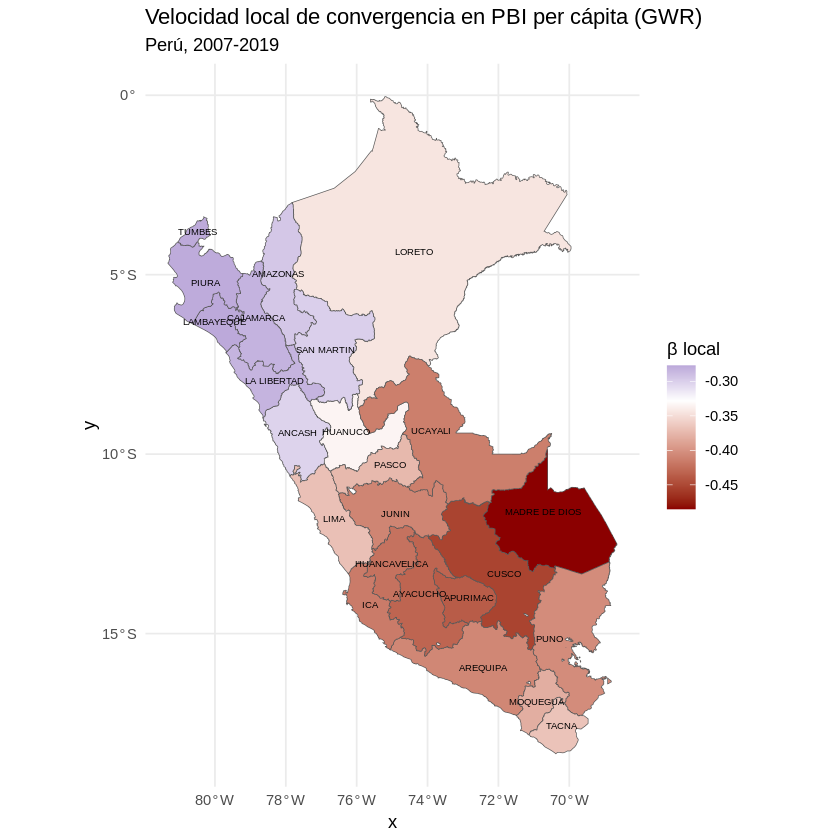

In [45]:
mapa_datos$beta_local_rgdpc <- gwr_rgdpc$SDF$ln_rgdpc_2007



# Mapa simple con ggplot2

install.packages("ggplot2")

library(ggplot2)



ggplot(mapa_datos) +

  geom_sf(aes(fill = beta_local_rgdpc)) +

  scale_fill_gradient2(low = "darkred", mid = "white", high = "darkblue",

                        midpoint = -0.328, name = "β local") +

  geom_sf_text(aes(label = clave), size = 2, color = "black") +

  labs(title = "Velocidad local de convergencia en PBI per cápita (GWR)",

       subtitle = "Perú, 2007-2019") +

  theme_minimal()

## 8. Regresión no paramétrica (LOESS / Kernel)

Call:
loess(formula = d_dev ~ idh_2007, data = mapa_datos, span = 0.75, 
    degree = 1)

Number of Observations: 24 
Equivalent Number of Parameters: 3 
Residual Standard Error: 0.02412 
Trace of smoother matrix: 3.48  (exact)

Control settings:
  span     :  0.75 
  degree   :  1 
  family   :  gaussian
  surface  :  interpolate	  cell = 0.2
  normalize:  TRUE
 parametric:  FALSE
drop.square:  FALSE 

Call:
loess(formula = d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos, span = 0.75, 
    degree = 1)

Number of Observations: 24 
Equivalent Number of Parameters: 3.2 
Residual Standard Error: 0.2313 
Trace of smoother matrix: 3.74  (exact)

Control settings:
  span     :  0.75 
  degree   :  1 
  family   :  gaussian
  surface  :  interpolate	  cell = 0.2
  normalize:  TRUE
 parametric:  FALSE
drop.square:  FALSE 

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


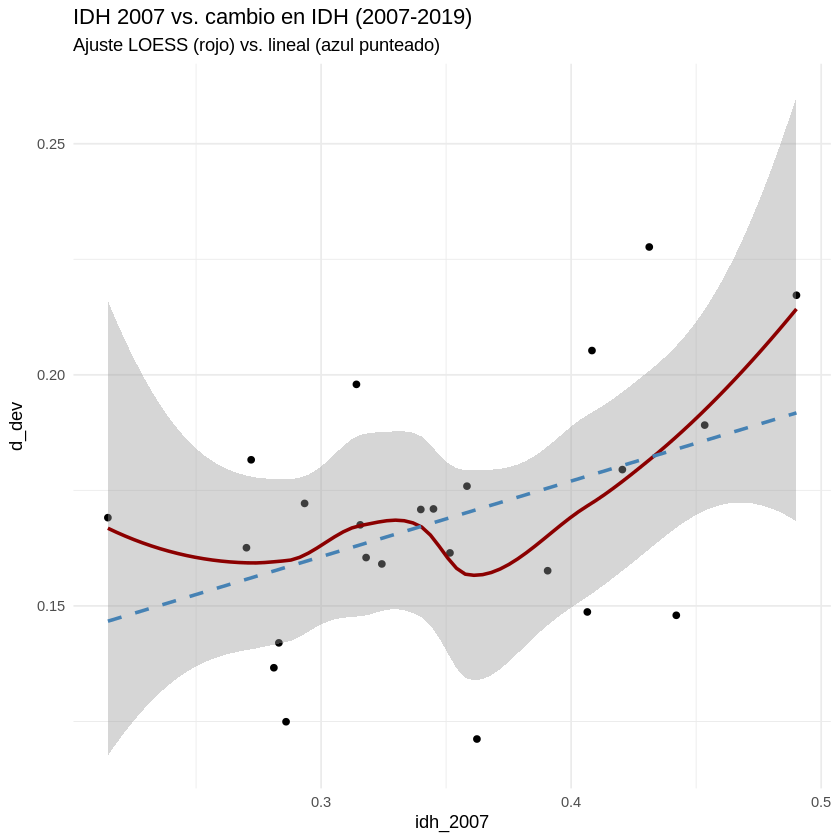

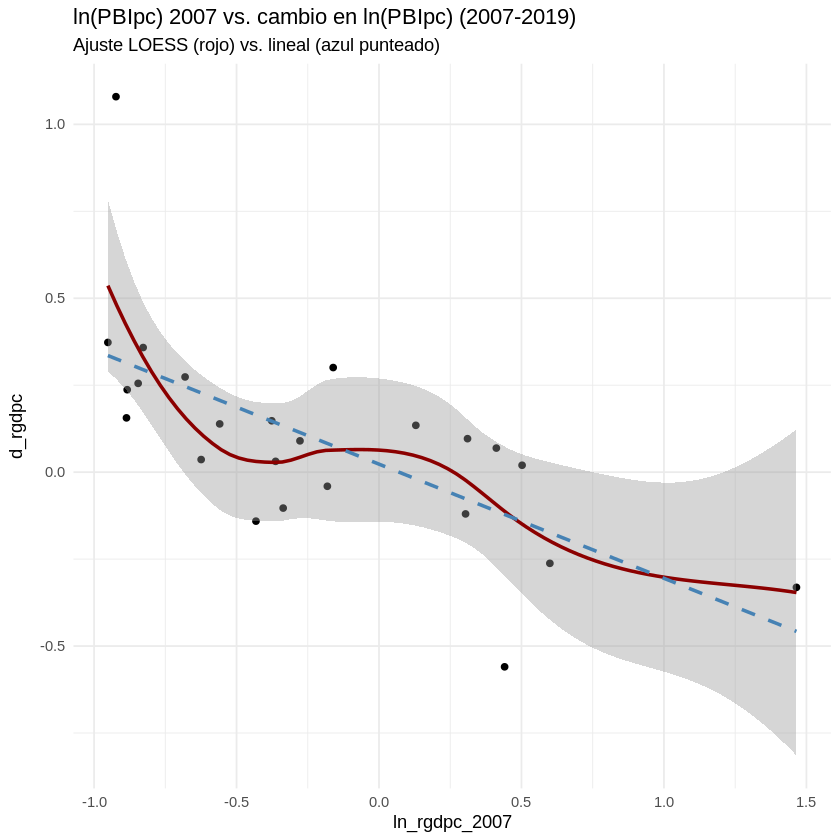

In [46]:
# ===== Para IDH (Ecuación 9 del paper) =====

loess_dev <- loess(d_dev ~ idh_2007, data = mapa_datos, span = 0.75, degree = 1)

summary(loess_dev)



# ===== Para PBI per cápita (Ecuación 10) =====

loess_rgdpc <- loess(d_rgdpc ~ ln_rgdpc_2007, data = mapa_datos, span = 0.75, degree = 1)

summary(loess_rgdpc)



# ===== Gráficos =====

library(ggplot2)



p1 <- ggplot(mapa_datos, aes(x = idh_2007, y = d_dev)) +

  geom_point() +

  geom_smooth(method = "loess", span = 0.75, color = "darkred") +

  geom_smooth(method = "lm", color = "steelblue", linetype = "dashed", se = FALSE) +

  labs(title = "IDH 2007 vs. cambio en IDH (2007-2019)",

       subtitle = "Ajuste LOESS (rojo) vs. lineal (azul punteado)") +

  theme_minimal()



p2 <- ggplot(mapa_datos, aes(x = ln_rgdpc_2007, y = d_rgdpc)) +

  geom_point() +

  geom_smooth(method = "loess", span = 0.75, color = "darkred") +

  geom_smooth(method = "lm", color = "steelblue", linetype = "dashed", se = FALSE) +

  labs(title = "ln(PBIpc) 2007 vs. cambio en ln(PBIpc) (2007-2019)",

       subtitle = "Ajuste LOESS (rojo) vs. lineal (azul punteado)") +

  theme_minimal()



print(p1)

print(p2)

### 📊 Interpretación — Regresión no paramétrica (LOESS)

| | N | Parámetros equivalentes | Error estándar residual |
|---|---|---|---|
| d_dev ~ idh_2007 | 24 | 3.0 | 0.0241 |
| d_rgdpc ~ ln_rgdpc_2007 | 24 | 3.2 | 0.2313 |

**Lectura crítica**

Para el **IDH**, la curva LOESS se aparta de la recta lineal (valle en IDH≈0.35-0.40, salto en Lima) → sugiere no-linealidad real.

Para el **PBI per cápita**, la curva LOESS se ajusta mucho más a la línea recta → relación predominantemente lineal, con Apurímac (efecto Las Bambas) como atípico.


Figura 1: Densidad kernel del IDH

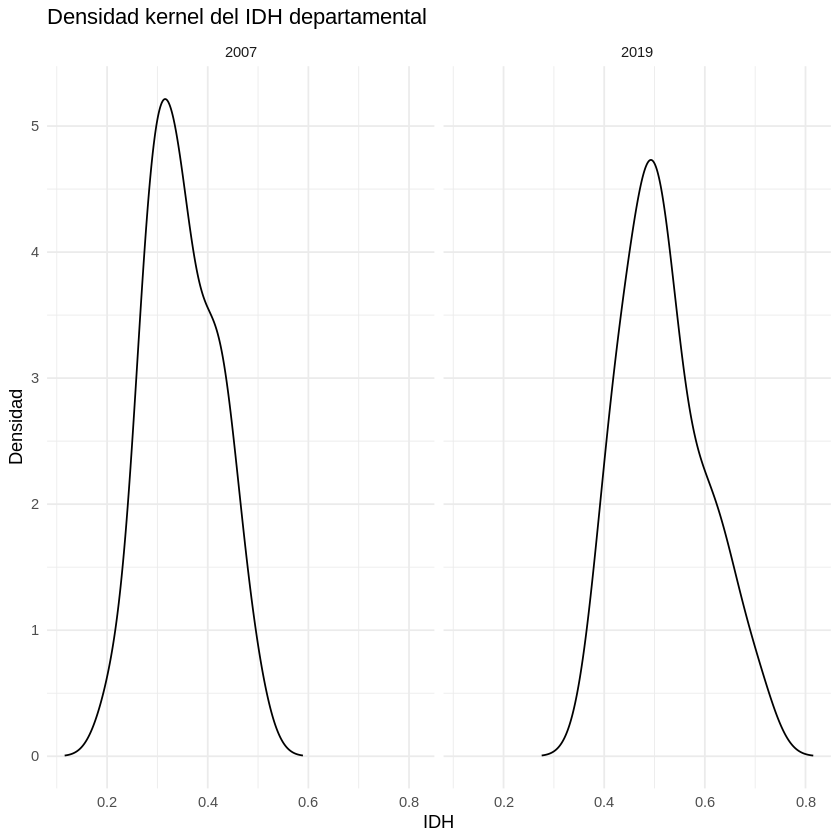

In [47]:
dens_2007 <- density(mapa_datos$idh_2007)

dens_2019 <- density(mapa_datos$idh_2019)



df_dens <- bind_rows(

  data.frame(x = dens_2007$x, y = dens_2007$y, anio = "2007"),

  data.frame(x = dens_2019$x, y = dens_2019$y, anio = "2019")

)



ggplot(df_dens, aes(x = x, y = y)) +

  geom_line() +

  facet_wrap(~anio) +

  labs(title = "Densidad kernel del IDH departamental", x = "IDH", y = "Densidad") +

  theme_minimal()

Figura 2: Mapas coropléticos (nivel y cambio)

In [48]:
install.packages("patchwork")

library(patchwork)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



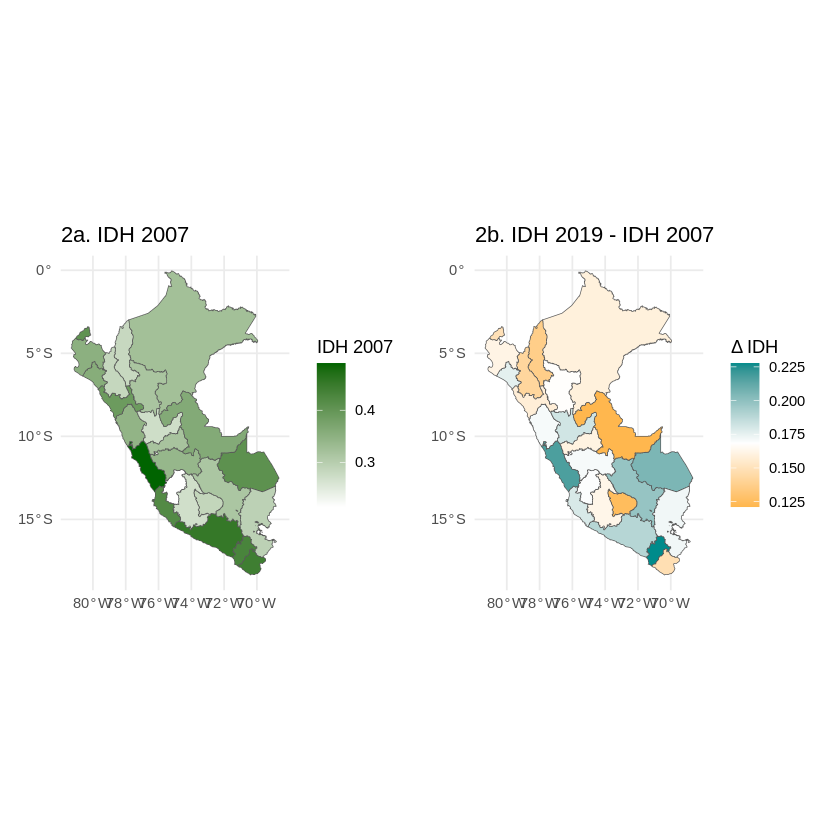

In [49]:
mapa_nivel <- ggplot(mapa_datos) +

  geom_sf(aes(fill = idh_2007)) +

  scale_fill_gradient(low = "white", high = "darkgreen", name = "IDH 2007") +

  labs(title = "2a. IDH 2007") + theme_minimal()



mapa_cambio <- ggplot(mapa_datos) +

  geom_sf(aes(fill = d_dev)) +

  scale_fill_gradient2(low = "orange", mid = "white", high = "darkcyan",

                        midpoint = median(mapa_datos$d_dev), name = "Δ IDH") +

  labs(title = "2b. IDH 2019 - IDH 2007") + theme_minimal()



mapa_nivel + mapa_cambio

2a. IDH 2007 — el patrón esperado: Lima y el sur (Arequipa, Tacna, Moquegua) en verde oscuro (mayor desarrollo), mientras el centro-sur andino (Huancavelica, Ayacucho, Apurímac) y el nororiente (Amazonas) aparecen en verde claro (menor desarrollo inicial).2b. Cambio 2007-2019 — aquí está lo interesante: los tonos naranjas (menor progreso, Δ≈0.125-0.15) se concentran en el norte y noroccidente (Piura, Lambayeque, Cajamarca, La Libertad), mientras los tonos azules/turquesa (mayor progreso, Δ≈0.20-0.225) aparecen dispersos en el centro-sur y algunas zonas puntuales. Este patrón norte-menos/sur-más es coherente con el mismo hallazgo que ya viste en el mapa de GWR del PBI per cápita — hay una consistencia geográfica entre cómo evoluciona el ingreso y cómo evoluciona el desarrollo, aunque estadísticamente uno converge y el otro diverge.

Figura 3: Moran scatterplot (el gráfico, no solo el número)

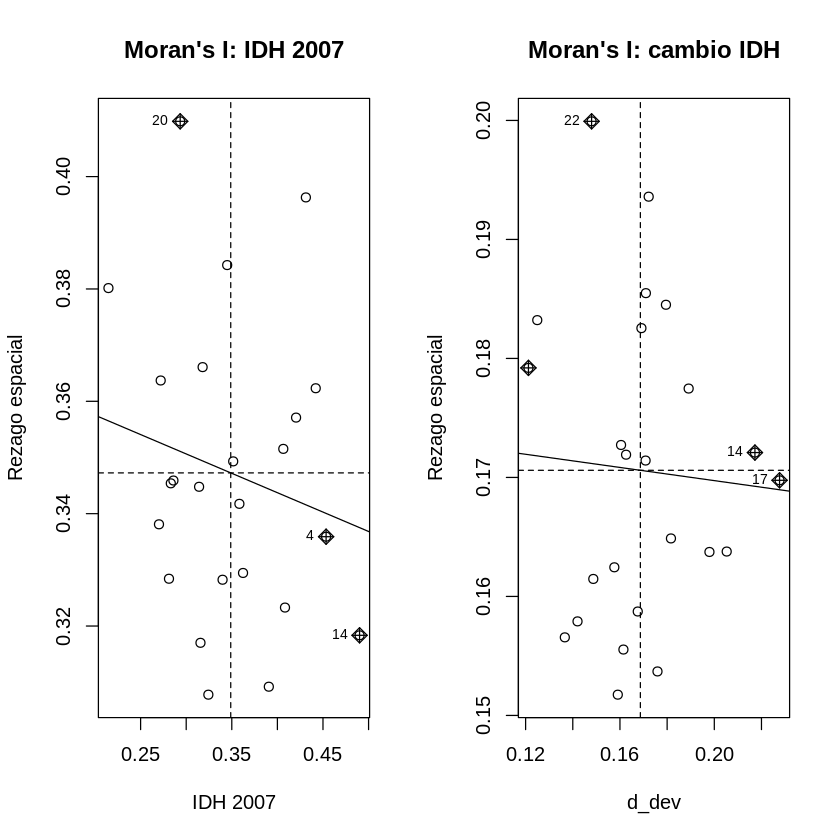

In [50]:
par(mfrow = c(1, 2))

moran.plot(mapa_datos$idh_2007, W_queen, zero.policy = TRUE,

           xlab = "IDH 2007", ylab = "Rezago espacial", main = "Moran's I: IDH 2007")

moran.plot(mapa_datos$d_dev, W_queen, zero.policy = TRUE,

           xlab = "d_dev", ylab = "Rezago espacial", main = "Moran's I: cambio IDH")

Figura 4: Los 4 paneles de GWR (R² local + β local, para ambas variables)

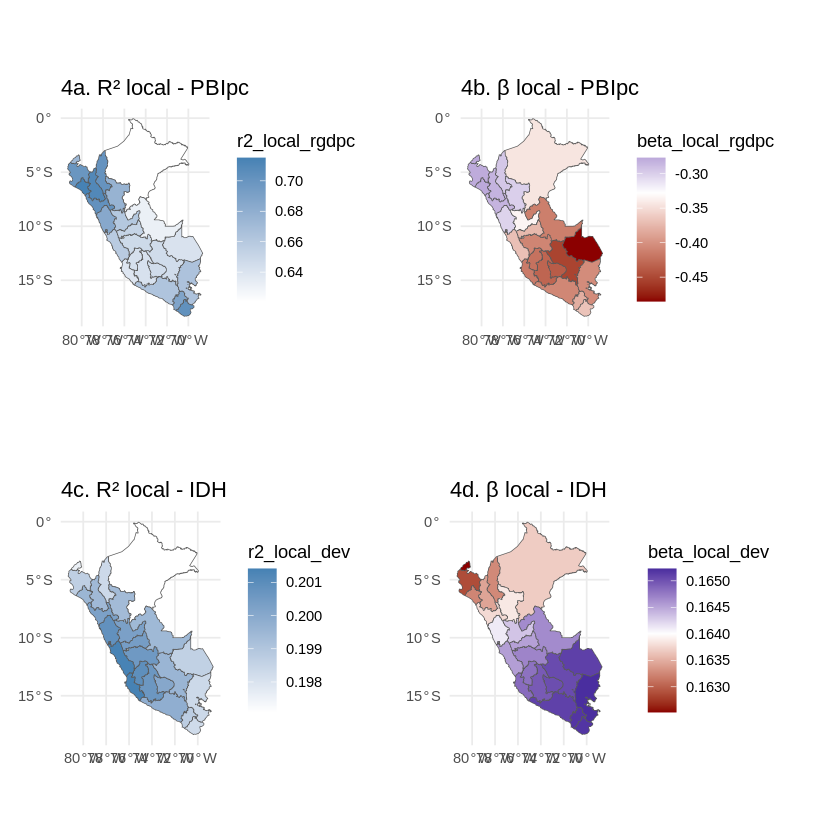

In [51]:
mapa_datos$r2_local_dev    <- gwr_dev$SDF$localR2

mapa_datos$beta_local_dev  <- gwr_dev$SDF$idh_2007

mapa_datos$r2_local_rgdpc  <- gwr_rgdpc$SDF$localR2

# beta_local_rgdpc ya lo tienes de antes



p4a <- ggplot(mapa_datos) + geom_sf(aes(fill = r2_local_rgdpc)) +

  scale_fill_gradient(low="white", high="steelblue") + labs(title="4a. R² local - PBIpc") + theme_minimal()

p4b <- ggplot(mapa_datos) + geom_sf(aes(fill = beta_local_rgdpc)) +

  scale_fill_gradient2(low="darkred", mid="white", high="darkblue", midpoint=-0.328) + labs(title="4b. β local - PBIpc") + theme_minimal()

p4c <- ggplot(mapa_datos) + geom_sf(aes(fill = r2_local_dev)) +

  scale_fill_gradient(low="white", high="steelblue") + labs(title="4c. R² local - IDH") + theme_minimal()

p4d <- ggplot(mapa_datos) + geom_sf(aes(fill = beta_local_dev)) +

  scale_fill_gradient2(low="darkred", mid="white", high="darkblue", midpoint=0.164) + labs(title="4d. β local - IDH") + theme_minimal()



(p4a + p4b) / (p4c + p4d)

Figura 5: Agregar el ajuste Kernel (te faltaba, solo tenías Lineal + LOESS)

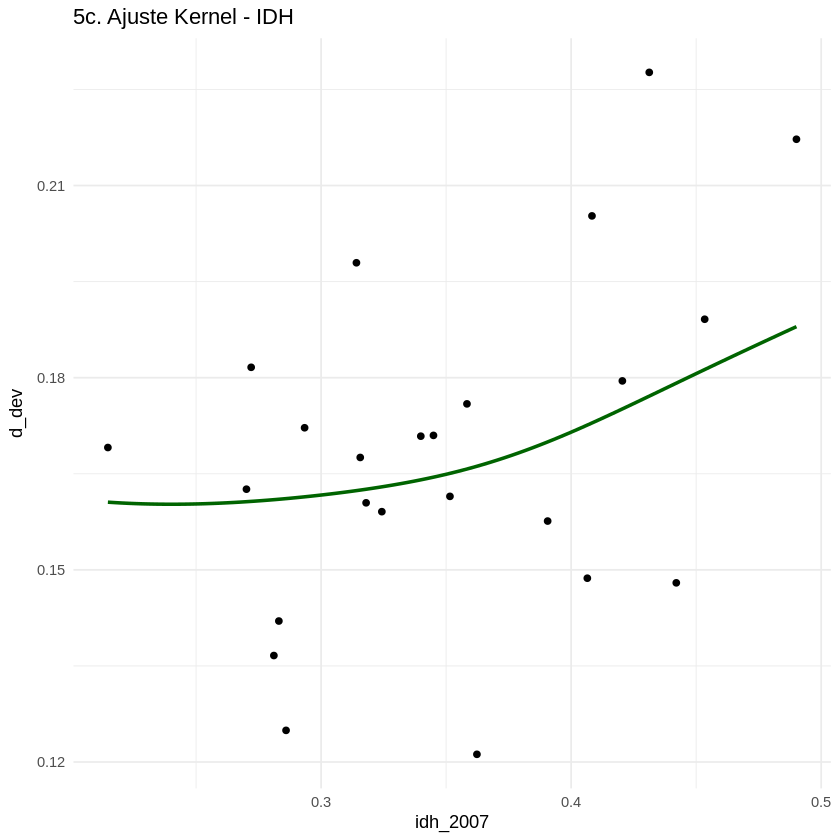

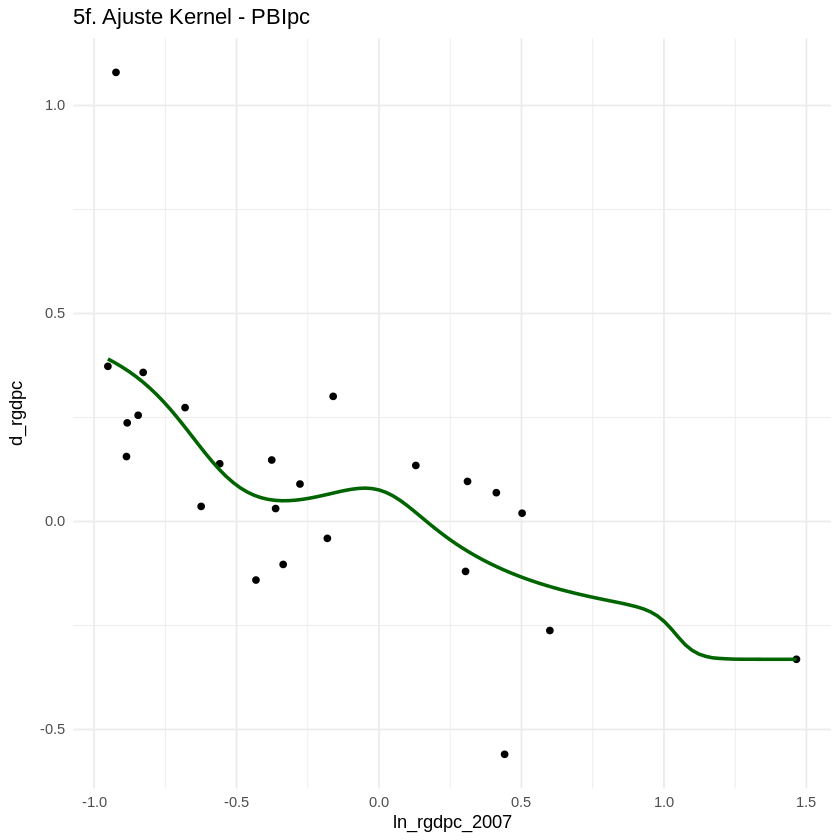

In [56]:
kernel_dev <- ksmooth(mapa_datos$idh_2007, mapa_datos$d_dev, kernel = "normal", bandwidth = 0.15)

kernel_rgdpc <- ksmooth(mapa_datos$ln_rgdpc_2007, mapa_datos$d_rgdpc, kernel = "normal", bandwidth = 0.5)



p3 <- ggplot(mapa_datos, aes(x = idh_2007, y = d_dev)) +

  geom_point() +

  geom_line(data = data.frame(x = kernel_dev$x, y = kernel_dev$y), aes(x = x, y = y), color = "darkgreen", linewidth = 1) +

  labs(title = "5c. Ajuste Kernel - IDH") + theme_minimal()



p4 <- ggplot(mapa_datos, aes(x = ln_rgdpc_2007, y = d_rgdpc)) +

  geom_point() +

  geom_line(data = data.frame(x = kernel_rgdpc$x, y = kernel_rgdpc$y), aes(x = x, y = y), color = "darkgreen", linewidth = 1) +

  labs(title = "5f. Ajuste Kernel - PBIpc") + theme_minimal()



print(p3); print(p4)

## 🎯 Resumen de hallazgos principales

| Dimensión | IDH (desarrollo) | PBI per cápita (ingreso) |
|---|---|---|
| Patrón 2007-2019 | **Divergencia** (β=+0.164 a +0.188) | **Convergencia** (β=-0.328 a -0.379) |
| Dependencia espacial (Moran's I) | No significativa (robusta a 5 especificaciones) | Significativa vía LM y SEM (Lambda=0.630***) |
| Heterogeneidad local (GWR) | Nula (bandwidth no converge) | Real (β local: -0.277 a -0.485; patrón norte-sur) |
| No linealidad (LOESS) | Presente (valle + salto en Lima) | Leve (predominantemente lineal) |

**Contraste con Duran et al. (2024, Turquía):** en Turquía, desarrollo e ingreso convergían y mostraban dependencia espacial. En Perú el patrón se divide: el ingreso converge (como en Turquía) pero el desarrollo diverge (a diferencia de Turquía).


In [57]:
dir.create("figures", showWarnings = FALSE)

# ===== Figura 1: Densidad kernel del IDH =====
dens_2007 <- density(mapa_datos$idh_2007)
dens_2019 <- density(mapa_datos$idh_2019)
df_dens <- bind_rows(
  data.frame(x = dens_2007$x, y = dens_2007$y, anio = "2007"),
  data.frame(x = dens_2019$x, y = dens_2019$y, anio = "2019")
)
fig1 <- ggplot(df_dens, aes(x = x, y = y)) +
  geom_line() + facet_wrap(~anio) +
  labs(title = "Densidad kernel del IDH departamental", x = "IDH", y = "Densidad") +
  theme_minimal()
ggsave("figures/fig1_densidad_kernel.png", plot = fig1, width = 8, height = 4, dpi = 300)

# ===== Figura 2: Mapas de nivel y cambio (IDH) =====
fig2 <- mapa_nivel + mapa_cambio
ggsave("figures/fig2_mapas_idh.png", plot = fig2, width = 10, height = 5, dpi = 300)

# ===== Figura 3: Moran scatterplot (gráfico base R, se guarda distinto) =====
png("figures/fig3_moran_scatter.png", width = 1000, height = 500, res = 120)
par(mfrow = c(1, 2))
moran.plot(mapa_datos$idh_2007, W_queen, zero.policy = TRUE, xlab = "IDH 2007", ylab = "Rezago espacial")
moran.plot(mapa_datos$d_dev, W_queen, zero.policy = TRUE, xlab = "d_dev", ylab = "Rezago espacial")
dev.off()

# ===== Figura 4: Paneles GWR (R² local y β local, ambas variables) =====
fig4 <- (p4a + p4b) / (p4c + p4d)
ggsave("figures/fig4_gwr_paneles.png", plot = fig4, width = 10, height = 8, dpi = 300)

# ===== Figura 5: Mapa β local (PBI per cápita) =====
ggsave("figures/fig5_gwr_mapa_beta.png", plot = p_gwr, width = 8, height = 6, dpi = 300)

# ===== Figura 6-7: LOESS (lineal vs LOESS) =====
ggsave("figures/fig6_loess_idh.png", plot = p1, width = 6, height = 5, dpi = 300)
ggsave("figures/fig7_loess_rgdpc.png", plot = p2, width = 6, height = 5, dpi = 300)

# ===== Figura 8-9: Kernel =====
ggsave("figures/fig8_kernel_idh.png", plot = p3, width = 6, height = 5, dpi = 300)
ggsave("figures/fig9_kernel_rgdpc.png", plot = p4, width = 6, height = 5, dpi = 300)

# ===== Comprimir todo en un solo zip para descargar de una vez =====
zip("figures.zip", list.files("figures", full.names = TRUE))
cat("Listo. Archivos generados:\n")
print(list.files("figures"))

agg_record_52d33b46815 
                     2

Warning message in st_point_on_surface.sfc(sf::st_zm(x)):
“st_point_on_surface may not give correct results for longitude/latitude data”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


Listo. Archivos generados:
[1] "fig1_densidad_kernel.png" "fig2_mapas_idh.png"      
[3] "fig3_moran_scatter.png"   "fig4_gwr_paneles.png"    
[5] "fig5_gwr_mapa_beta.png"   "fig6_loess_idh.png"      
[7] "fig7_loess_rgdpc.png"     "fig8_kernel_idh.png"     
[9] "fig9_kernel_rgdpc.png"   
